# Train and test string embeddings

Tiny end-to-end workflow: load test words, train the CNN triplet model, then compare learned nearest neighbors with edit distance.

The default word list comes from `data/words_alpha.txt`. This notebook currently uses `load_words(limit=10_000)` to keep training manageable; use `load_words()` to train on all 370,105 words.

In [11]:
from importlib import reload
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import train as train_module
from testdata import load_words

train_module = reload(train_module)
nearest = train_module.nearest
normalized_levenshtein_similarity = train_module.normalized_levenshtein_similarity
train = train_module.train

device = "cuda" if torch.cuda.is_available() else "cpu"
similarity_fn = normalized_levenshtein_similarity
words = load_words(limit=10_000)
device, similarity_fn.__name__, len(words), words[:10]

('cuda',
 'normalized_levenshtein_similarity',
 407,
 ['aachen',
  'aachens',
  'aardvark',
  'aardvarks',
  'aback',
  'abacus',
  'abacuses',
  'abaft',
  'abandon',
  'abandoned'])

In [ ]:
checkpoint_path = Path("string_embed.pt")
result = train(words, epochs=1_000, batch_size=2048, embed_dim=256, lr=0.01, progress=True, device=device, similarity_fn=similarity_fn)
checkpoint_path, result.device.type, result.losses[-1]

Training: 100%|██████████| 1000/1000 [00:52<00:00, 18.87epoch/s, device=cuda, loss=0.1617]


(PosixPath('string_embed.pt'), 'cuda', 0.16166396651949203)

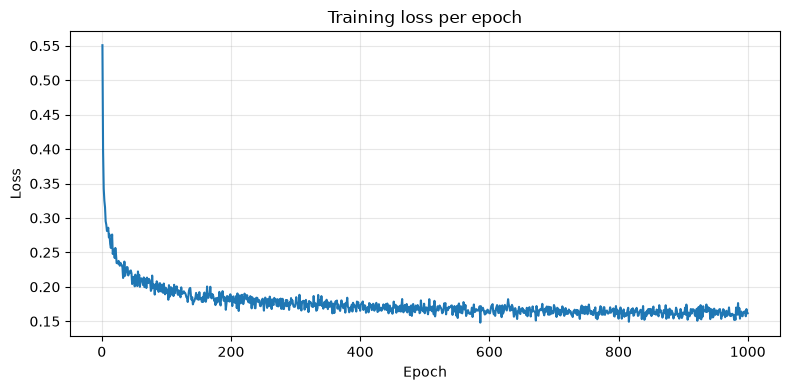

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(result.losses) + 1), result.losses)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training loss per epoch")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [14]:
for query in ["apple", "market", "winter", "rocket"]:
    print(query)
    for word, embedding_distance, edit_distance in nearest(result.model, query, words, n=5):
        print(f"  {word:12s} embedding={embedding_distance:.3f} edit={edit_distance:.3f} delta={embedding_distance-edit_distance:.3f}")

apple
  apple        embedding=0.000 edit=0.000 delta=0.000
  apply        embedding=0.239 edit=0.200 delta=0.039
  alive        embedding=0.303 edit=0.600 delta=-0.297
  agree        embedding=0.337 edit=0.600 delta=-0.263
  arise        embedding=0.344 edit=0.600 delta=-0.256
market
  market       embedding=0.000 edit=0.000 delta=0.000
  jacket       embedding=0.290 edit=0.333 delta=-0.043
  alike        embedding=0.299 edit=0.667 delta=-0.368
  basket       embedding=0.312 edit=0.333 delta=-0.021
  target       embedding=0.325 edit=0.333 delta=-0.008
winter
  winter       embedding=0.000 edit=0.000 delta=0.000
  copper       embedding=0.286 edit=0.667 delta=-0.381
  writer       embedding=0.295 edit=0.333 delta=-0.038
  finder       embedding=0.297 edit=0.333 delta=-0.036
  center       embedding=0.301 edit=0.333 delta=-0.033
rocket
  rocket       embedding=0.000 edit=0.000 delta=0.000
  pocket       embedding=0.133 edit=0.167 delta=-0.034
  jacket       embedding=0.263 edit=0.333 d

In [15]:
def save_model(result, path, similarity_fn):
    path = Path(path)
    checkpoint = {
        "model_state_dict": {key: value.cpu() for key, value in result.model.state_dict().items()},
        "max_len": result.model.max_len,
        "losses": result.losses,
        "device": result.device.type,
        "similarity_fn": similarity_fn.__name__,
        "word_count": len(result.dataset.words),
    }
    torch.save(checkpoint, path)
    return path


save_model(result, checkpoint_path, similarity_fn)

PosixPath('string_embed.pt')